# Homework 1 — Optimizers

mlp_4out_mean and mlp_4out_emb from [mlp.ipynb](mlp.ipynb), trained with four optimizers
([Lecture 2](../../../Module_1/Lecture_2/gradients_are_our_best_friends.ipynb)):

| Optimizer | Update | Learning rate |
| --- | --- | --- |
| **SGD** | step against the gradient of each mini-batch | 0.1 |
| **Momentum** | SGD plus a running average of past steps (momentum 0.9), which smooths the direction | 0.01 |
| **Nesterov** | momentum, but the gradient is taken at the point the momentum is about to reach | 0.01 |
| **Adam** | momentum plus a per-parameter step size, scaled by each gradient's recent magnitude | 0.001 |

Each gets its usual learning rate: plain SGD needs a larger one than Adam; with momentum 0.9 the effective step is
~10× the learning rate. The 4 seasonal folds of mlp.ipynb (2M training / 500K validation rows each); optimizers are
compared by the fold average. 20 epochs, since SGD converges slowly.

In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

sys.path.insert(0, "..")  # the ashrae package lives in the homework folder
from ashrae.config import FOLDS
from ashrae.data import read_processed, split
from ashrae.features import add_series_mean, build_features
from ashrae.modeling import MeterMLP, make_loaders
from ashrae.plots import plot_curves
from ashrae.tracking import Experiment

EPOCHS = 20
N_TRAIN, N_VAL = 2_000_000, 500_000  # rows sampled per fold, as in the other notebooks
OPTIMIZERS = {
    "SGD": lambda params: torch.optim.SGD(params, lr=0.1),
    "Momentum": lambda params: torch.optim.SGD(params, lr=0.01, momentum=0.9),
    "Nesterov": lambda params: torch.optim.SGD(params, lr=0.01, momentum=0.9, nesterov=True),
    "Adam": lambda params: torch.optim.Adam(params, lr=1e-3),
}
experiment = Experiment("ashrae-optimizers")

MLflow: sqlite:////Users/lupaskodmitro/FuckIT/Machine Learning/Deep Learning Course/Homeworks/Homework 1/mlflow.db, experiment 'ashrae-optimizers', session 2026-09-27 15:38:31


## Data, features and models

As in [mlp.ipynb](mlp.ipynb): mlp_4out_mean gets the series mean as an extra input, mlp_4out_emb a 16-number
building embedding.

In [2]:
df = read_processed()
n_buildings = int(df.building_id.max()) + 1


def fold_loaders(val_months):
    train_df, val_df = split(df, val_months, N_TRAIN, N_VAL)
    year_median = train_df.year_built.median()
    X_train, X_val = build_features(train_df, year_median), build_features(val_df, year_median)
    return {
        "mlp_4out_mean": make_loaders(train_df, val_df, add_series_mean(X_train, train_df, train_df),
                                      add_series_mean(X_val, val_df, train_df)),
        "mlp_4out_emb": make_loaders(train_df, val_df, X_train, X_val),
    }


folds = {name: fold_loaders(months) for name, months in FOLDS.items()}
n_features = folds["Jan–Mar"]["mlp_4out_emb"][0].dataset.x.shape[1]
del df
MODELS = {"mlp_4out_mean": lambda: MeterMLP(n_features + 1), "mlp_4out_emb": lambda: MeterMLP(n_features, n_buildings)}

## Training

32 runs: 2 models × 4 optimizers × 4 folds, each logged to MLflow with its per-epoch training and validation RMSLE
(validation on all rows).

In [3]:
def train(model_name, optimizer, fold):
    train_loader, val_loader, _ = folds[fold][model_name]
    _, run_id = experiment.fit(MODELS[model_name], train_loader, val_loader,
                               run_name=f"{model_name} | {optimizer} | {fold}", epochs=EPOCHS,
                               tags={"model": model_name, "optimizer": optimizer, "fold": fold},
                               optimizer=OPTIMIZERS[optimizer])
    return {"model": model_name, "optimizer": optimizer, "fold": fold,
            "train": experiment.history(run_id, "train_rmsle"), "val": experiment.history(run_id, "val_rmsle")}


runs = []
for fold in FOLDS:
    for model_name in MODELS:
        for optimizer in OPTIMIZERS:
            runs.append(train(model_name, optimizer, fold))
            print(f"{fold} {model_name:14s} {optimizer:9s} val RMSLE, mean of last 5 epochs: "
                  f"{np.mean(runs[-1]['val'][-5:]):.4f}")
runs = pd.DataFrame(runs)
curves = {key: {k: np.mean(group[k].tolist(), axis=0) for k in ["train", "val"]}  # mean over folds, per epoch
          for key, group in runs.groupby(["model", "optimizer"], sort=False)}

Jan–Mar mlp_4out_mean  SGD       val RMSLE, mean of last 5 epochs: 1.4497


Jan–Mar mlp_4out_mean  Momentum  val RMSLE, mean of last 5 epochs: 1.4483


Jan–Mar mlp_4out_mean  Nesterov  val RMSLE, mean of last 5 epochs: 1.4451


Jan–Mar mlp_4out_mean  Adam      val RMSLE, mean of last 5 epochs: 1.4493


Jan–Mar mlp_4out_emb   SGD       val RMSLE, mean of last 5 epochs: 1.4454


...

Oct–Dec mlp_4out_mean  Adam      val RMSLE, mean of last 5 epochs: 1.1192


Oct–Dec mlp_4out_emb   SGD       val RMSLE, mean of last 5 epochs: 1.1350


Oct–Dec mlp_4out_emb   Momentum  val RMSLE, mean of last 5 epochs: 1.1122


Oct–Dec mlp_4out_emb   Nesterov  val RMSLE, mean of last 5 epochs: 1.1182


Oct–Dec mlp_4out_emb   Adam      val RMSLE, mean of last 5 epochs: 1.1003


## Each model, all optimizers

model,mlp_4out_mean,mlp_4out_emb,both models,epoch-to-epoch swing
fold average,,,,
SGD,1.2463,1.2285,1.2374,0.0158
Momentum,1.2347,1.2105,1.2226,0.0053
Nesterov,1.2332,1.2120,1.2226,0.0059
Adam,1.2358,1.1898,1.2128,0.0036


fold,Jan–Mar,Apr–Jun,Jul–Sep,Oct–Dec
"both models, per fold",,,,
SGD,1.4476,1.2475,1.1235,1.1311
Momentum,1.4362,1.2393,1.0985,1.1163
Nesterov,1.4368,1.2379,1.0977,1.1178
Adam,1.4316,1.2324,1.0775,1.1098


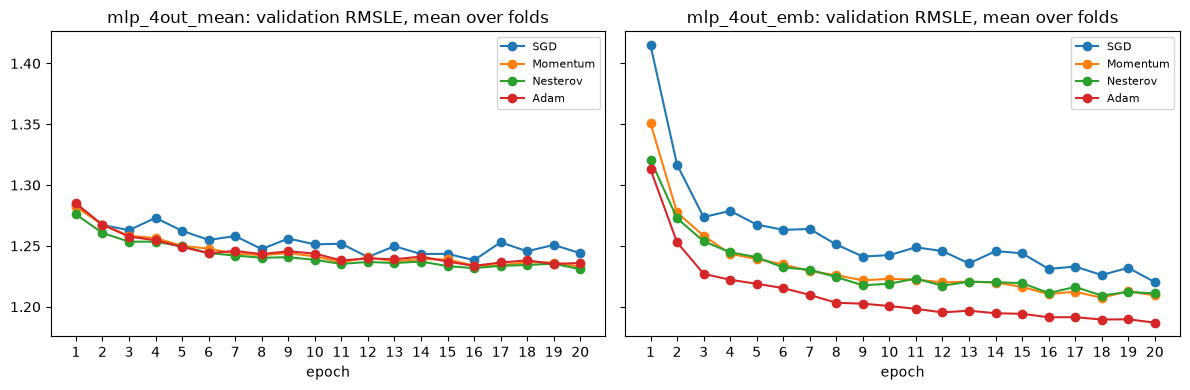

In [4]:
epochs = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, model_name in zip(axes, MODELS):
    plot_curves(ax, {opt: curves[(model_name, opt)]["val"].tolist() for opt in OPTIMIZERS},
                f"{model_name}: validation RMSLE, mean over folds")
plt.tight_layout()

# per run: mean of the last 5 epochs (single-epoch scores swing by up to ±0.02 for the SGD-based optimizers), and the
# mean change between consecutive epochs over the last 10
runs["last5"] = runs.val.map(lambda v: np.mean(v[-5:]))
runs["swing"] = runs.val.map(lambda v: np.mean(np.abs(np.diff(v[-10:]))))
final = runs.pivot_table(index="optimizer", columns="model", values="last5").loc[list(OPTIMIZERS), list(MODELS)]
final["both models"] = final.mean(axis=1)
final["epoch-to-epoch swing"] = runs.groupby("optimizer").swing.mean()
display(final.round(4).rename_axis("fold average"))
per_fold = runs.pivot_table(index="optimizer", columns="fold", values="last5").loc[list(OPTIMIZERS), list(FOLDS)]
display(per_fold.round(4).rename_axis("both models, per fold"))

## Best optimizer, both models

Best = lowest validation RMSLE over the last 5 epochs, averaged over both models and all folds. Solid lines:
validation; dashed: training; both averaged over folds.

best optimizer: Adam


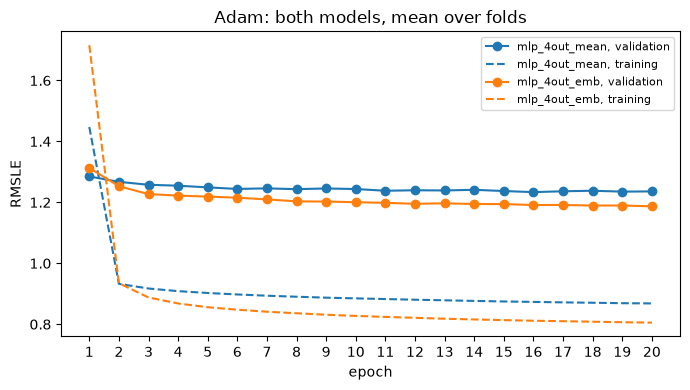

In [5]:
best = final["both models"].idxmin()
fig, ax = plt.subplots(figsize=(7, 4))
for model_name, color in zip(MODELS, ["tab:blue", "tab:orange"]):
    ax.plot(epochs, curves[(model_name, best)]["val"], marker="o", color=color, label=f"{model_name}, validation")
    ax.plot(epochs, curves[(model_name, best)]["train"], ls="--", color=color, label=f"{model_name}, training")
ax.set(title=f"{best}: both models, mean over folds", xlabel="epoch", ylabel="RMSLE", xticks=epochs)
ax.legend(fontsize=8)
plt.tight_layout()
print(f"best optimizer: {best}")

## Findings

Scores: mean validation RMSLE over the last 5 of 20 epochs, averaged over the 4 folds (all rows).

- **Adam is best overall:** 1.213 averaged over both models; momentum and Nesterov 1.223, SGD 1.237. It's best in
  every fold, and its lead comes from the embedding model.
- **mlp_4out_mean:** momentum, Nesterov and Adam within 0.003 (1.233–1.236), SGD 1.246. The optimizer barely matters.
- **mlp_4out_emb:** Adam wins clearly (1.190 vs 1.211–1.212 for momentum and Nesterov, 1.229 for SGD). A building's
  embedding gets gradient only from that building's rows, so its gradients are small. Adam scales each parameter's
  step to its own gradient size; SGD uses one learning rate for all.
- **Plain SGD is the least stable:** its score changes by 0.016 between consecutive epochs on average, 3–4× the
  others (0.004–0.006).
- **Adam's validation keeps improving to epoch 20** on the fold average; the epoch count is chosen in
  [epochs_test.ipynb](epochs_test.ipynb).

**Limits:** one seed, untuned learning rates.